In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [ ]:
#  UPDATE THIS PATH to your actual CSV file
DATASET_PATH = '/content/drive/MyDrive/Capstone/Project/vmCloud_data.csv'

df = pd.read_csv(DATASET_PATH)

print(f' Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\n Columns found: {list(df.columns)}')

 Dataset loaded: 2000000 rows, 12 columns

 Columns found: ['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'task_type', 'task_priority', 'task_status']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting


In [ ]:
df.dtypes

,0
vm_id,object
timestamp,object
cpu_usage,float64
memory_usage,float64
network_traffic,float64
power_consumption,float64
num_executed_instructions,float64
execution_time,float64
energy_efficiency,float64
task_type,object


In [ ]:
df.describe().round(3)

,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency
count,1800962.000,1799490.000,1800519.000,1799729.000,1800314.000,1800173.000,1799958.000
mean,50.012,49.982,500.008,250.058,5001.897,49.971,0.500
std,28.877,28.853,288.579,144.363,2885.247,28.861,0.289
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,24.977,25.004,250.067,124.970,2504.000,24.979,0.250
50%,50.055,49.976,500.008,250.247,5002.000,49.964,0.500
75%,75.029,74.956,749.817,375.107,7502.000,74.977,0.750
max,100.000,100.000,1000.000,499.999,9999.000,100.000,1.000


In [ ]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print(' No missing values found!')
else:
    print(' Missing values detected:')
    print(missing_report)

 No missing values found!


In [ ]:
# --- Fill missing values ---

# Numeric columns: fill with median (robust to outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  → {col}: filled with median ({df[col].median():.3f})')

# Categorical columns: fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  → {col}: filled with mode ({df[col].mode()[0]})')

print(f'\n Missing values handled. Remaining nulls: {df.isnull().sum().sum()}')


 Missing values handled. Remaining nulls: 0


In [ ]:
before=len(df)
df.drop_duplicates(inplace=True)
after =len(df)
print(f'Rows before: {before}')
print(f'Rows after:  {after}')
print(f'Duplicates removed: {before - after}')

Rows before: 2000000
Rows after:  2000000
Duplicates removed: 0


In [ ]:
if 'timestamp' in df.columns:
    # Parse as datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Sort by time — very important for time-series!
    df.sort_values('timestamp', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Extract useful time features
    df['hour']       = df['timestamp'].dt.hour
    df['dayofweek']  = df['timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
    df['dayofmonth'] = df['timestamp'].dt.day
    df['month']      = df['timestamp'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Drop the original timestamp column (we've extracted what we need)
    df.drop(columns=['timestamp'], inplace=True)

    print(' Timestamp parsed and time features extracted:')
    print('   → hour, dayofweek, dayofmonth, month, is_weekend')
else:
    print(' No timestamp column found — skipping this step.')

 Timestamp parsed and time features extracted:
   → hour, dayofweek, dayofmonth, month, is_weekend


In [ ]:
print(f"Unique VMs: {df['vm_id'].nunique()}")
print(df['vm_id'].value_counts().head(10))

Unique VMs: 1799362
vm_id
00001960-0da3-405c-a42a-67e6b4fa05e3    200639
ea2c66e0-2c02-4b37-880a-a582e5031582         1
aef59a34-53f8-4c5a-8a4b-95e4453bf473         1
02fbecec-f131-4d4a-b4e8-43a3231ac4ee         1
d6e2de97-3baf-4fcb-bc24-78632ca91667         1
b3e9ccdc-7b20-4a25-af34-96a5e9829e6f         1
1bdef75e-ba71-483c-9333-e6e479953551         1
94a4e072-c532-4c88-b870-e688f5290009         1
d7e10214-2ef2-47d5-a18a-12418754f997         1
d106baa7-f2b3-49f5-80e8-bd24203df4ca         1
Name: count, dtype: int64


In [ ]:
if 'vm_id' in df.columns:
    unique_vms = df['vm_id'].nunique()
    print(f'   Unique VMs found: {unique_vms}')
    print(f'   VM IDs: {df["vm_id"].unique()[:10]}')  # show only first 10

    # Drop vm_id — it's just a label, not a useful feature for ML
    df.drop(columns=['vm_id'], inplace=True)
    print(' vm_id dropped (identifier column — not useful for ML)')
else:
    print(' No vm_id column found — skipping.')

   Unique VMs found: 1799362
   VM IDs: ['a5ee77f0-5a60-474d-8a66-11bf38337326'
 '00001960-0da3-405c-a42a-67e6b4fa05e3'
 'fe5e04e3-4ea4-48cf-a193-3f58abd147ed'
 'caf092f0-55c3-4486-a295-f04a9a2c6406'
 'ca081259-cb36-4c07-a7db-5af5f8676930'
 'd894ae05-b16d-4df0-9b33-6b1f80ba3670'
 'c8e53b6b-07aa-4166-b588-a0c46ce29f3a'
 'b84abdaa-bf12-4d33-b9f1-421a8303947e'
 'f5db46e3-7d3c-46e6-8ee8-e4e592de5be1'
 'e9d43ae3-968d-4083-be68-ec3659f4a9c1']
 vm_id dropped (identifier column — not useful for ML)


In [ ]:
# Only encode these specific meaningful categorical columns
CATEGORICAL_COLS = ['task_type', 'task_priority', 'task_status']
cols_to_encode = [c for c in CATEGORICAL_COLS if c in df.columns]

label_encoders = {}

for col in cols_to_encode:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  → {col}: {mapping}')

# Drop the original string versions
df.drop(columns=cols_to_encode, inplace=True)

print(f'\n Encoding done! Encoded columns: {[c+"_encoded" for c in cols_to_encode]}')

  → task_type: {'compute': np.int64(0), 'io': np.int64(1), 'network': np.int64(2)}
  → task_priority: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
  → task_status: {'completed': np.int64(0), 'running': np.int64(1), 'waiting': np.int64(2)}

 Encoding done! Encoded columns: ['task_type_encoded', 'task_priority_encoded', 'task_status_encoded']


In [ ]:
# Confirm no more object columns remain
remaining_objects = df.select_dtypes(include=['object']).columns.tolist()
if remaining_objects:
    print(f' Still have object columns: {remaining_objects}')
    print('   → Drop them or handle them manually.')
    df.drop(columns=remaining_objects, inplace=True)
    print('   → Dropped automatically.')
else:
    print(' All columns are now numeric!')

 All columns are now numeric!


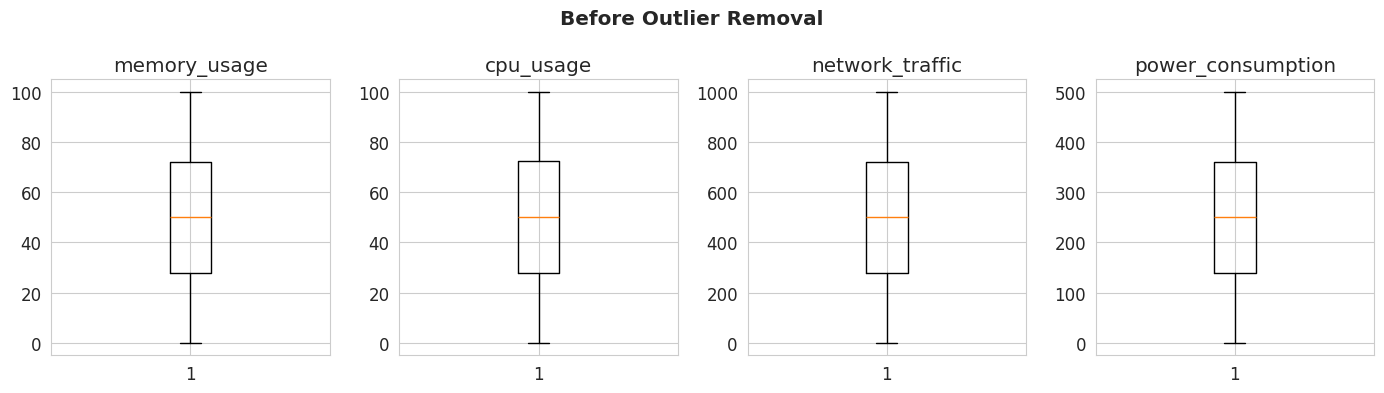

In [ ]:
# Visualize key columns before removal
key_cols = [c for c in ['memory_usage', 'cpu_usage', 'network_traffic', 'power_consumption'] if c in df.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(14, 4))
if len(key_cols) == 1:
    axes = [axes]
for i, col in enumerate(key_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Before Outlier Removal', fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_before.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
def remove_outliers_iqr(dataframe, columns, threshold=1.5):
    df_clean = dataframe.copy()
    total_removed = 0
    for col in columns:
        if col not in df_clean.columns:
            continue
        Q1  = df_clean[col].quantile(0.25)
        Q3  = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower  = Q1 - threshold * IQR
        upper  = Q3 + threshold * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed = before - len(df_clean)
        total_removed += removed
        print(f'  {col}: {removed} outliers removed')
    print(f'\nTotal removed: {total_removed} | Remaining rows: {len(df_clean)}')
    return df_clean

outlier_cols = [c for c in ['memory_usage', 'cpu_usage', 'network_traffic',
                             'power_consumption', 'execution_time'] if c in df.columns]
df = remove_outliers_iqr(df, outlier_cols)
df.reset_index(drop=True, inplace=True)
print('e Outlier removal done!')

  memory_usage: 0 outliers removed
  cpu_usage: 0 outliers removed
  network_traffic: 0 outliers removed
  power_consumption: 0 outliers removed
  execution_time: 0 outliers removed

Total removed: 0 | Remaining rows: 2000000
e Outlier removal done!


In [ ]:
# Rolling window features (captures recent trends)
if 'memory_usage' in df.columns:
    df['memory_roll_mean_5']  = df['memory_usage'].rolling(5,  min_periods=1).mean()
    df['memory_roll_mean_10'] = df['memory_usage'].rolling(10, min_periods=1).mean()
    df['memory_roll_std_5']   = df['memory_usage'].rolling(5,  min_periods=1).std().fillna(0)
    df['memory_roll_max_5']   = df['memory_usage'].rolling(5,  min_periods=1).max()

if 'cpu_usage' in df.columns:
    df['cpu_roll_mean_5'] = df['cpu_usage'].rolling(5, min_periods=1).mean()
    df['cpu_roll_std_5']  = df['cpu_usage'].rolling(5, min_periods=1).std().fillna(0)

print('Rolling features created')

Rolling features created


In [ ]:
# Lag features (what happened in previous timesteps)
if 'memory_usage' in df.columns:
    for lag in [1, 2, 3, 5]:
        df[f'memory_lag_{lag}'] = df['memory_usage'].shift(lag)

if 'cpu_usage' in df.columns:
    for lag in [1, 2, 3]:
        df[f'cpu_lag_{lag}'] = df['cpu_usage'].shift(lag)

# Drop NaN rows introduced by lag
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(' Lag features created')

 Lag features created


In [ ]:
# Rate of change features (spike detection signal)
if 'memory_usage' in df.columns:
    df['memory_rate_of_change'] = df['memory_usage'].diff().fillna(0)
    df['memory_pct_change']     = df['memory_usage'].pct_change().fillna(0).replace([np.inf, -np.inf], 0)

if 'cpu_usage' in df.columns:
    df['cpu_rate_of_change'] = df['cpu_usage'].diff().fillna(0)

# Interaction features
if 'memory_usage' in df.columns and 'cpu_usage' in df.columns:
    df['memory_cpu_product'] = df['memory_usage'] * df['cpu_usage']
    df['memory_cpu_ratio']   = df['memory_usage'] / (df['cpu_usage'] + 1e-6)

print(f' Rate-of-change & interaction features created')
print(f'   Total features now: {df.shape[1]}')

 Rate-of-change & interaction features created
   Total features now: 33


In [ ]:
df.shape

(1999995, 33)

Spike threshold (80th percentile) : 77.7082
Normal (0) : 1599996 rows  (80.0%)
Spike  (1) : 399999 rows  (20.0%)


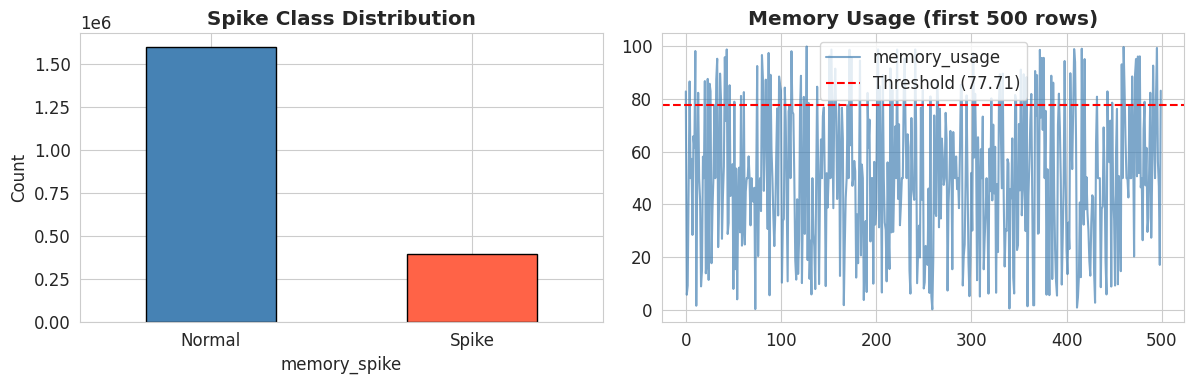

Target variable created!


In [ ]:
SPIKE_THRESHOLD = df['memory_usage'].quantile(0.80)
df['memory_spike'] = (df['memory_usage'] > SPIKE_THRESHOLD).astype(int)

counts = df['memory_spike'].value_counts()
print(f'Spike threshold (80th percentile) : {SPIKE_THRESHOLD:.4f}')
print(f'Normal (0) : {counts.get(0,0)} rows  ({counts.get(0,0)/len(df)*100:.1f}%)')
print(f'Spike  (1) : {counts.get(1,0)} rows  ({counts.get(1,0)/len(df)*100:.1f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Spike Class Distribution', fontweight='bold')
axes[0].set_xticklabels(['Normal', 'Spike'], rotation=0)
axes[0].set_ylabel('Count')

# Sample 500 points max to avoid IOPub overload
sample = df['memory_usage'].iloc[:500]
sample.plot(ax=axes[1], color='steelblue', alpha=0.7)
axes[1].axhline(SPIKE_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({SPIKE_THRESHOLD:.2f})')
axes[1].set_title('Memory Usage (first 500 rows)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('memory_spike_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Target variable created!')

In [ ]:
TARGET_COL   = 'memory_usage'
EXCLUDE_COLS = [TARGET_COL, 'memory_spike']

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print(f' Scaling done {len(feature_cols)} features scaled to [0, 1]')
print(f'   Feature list: {feature_cols}')

 Scaling done 32 features scaled to [0, 1]
   Feature list: ['cpu_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'hour', 'dayofweek', 'dayofmonth', 'month', 'is_weekend', 'task_type_encoded', 'task_priority_encoded', 'task_status_encoded', 'memory_roll_mean_5', 'memory_roll_mean_10', 'memory_roll_std_5', 'memory_roll_max_5', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'memory_lag_1', 'memory_lag_2', 'memory_lag_3', 'memory_lag_5', 'cpu_lag_1', 'cpu_lag_2', 'cpu_lag_3', 'memory_rate_of_change', 'memory_pct_change', 'cpu_rate_of_change', 'memory_cpu_product', 'memory_cpu_ratio']


In [ ]:
def create_sequences(data, target, window_size=10):
    """
    Creates sliding window sequences for LSTM.
    Output shape: X → (samples, timesteps, features), y → (samples,)
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10

X_data = df_scaled[feature_cols].values
y_data = df_scaled[TARGET_COL].values

X_seq, y_seq = create_sequences(X_data, y_data, WINDOW_SIZE)

print(f' Sequences created!')
print(f'   X shape : {X_seq.shape}  →  (samples, timesteps, features)')
print(f'   y shape : {y_seq.shape}')

 Sequences created!
   X shape : (1999985, 10, 32)  →  (samples, timesteps, features)
   y shape : (1999985,)


In [ ]:
# Time-series split — NO shuffle!
n = len(X_seq)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_seq[:train_end],        y_seq[:train_end]
X_val,   y_val   = X_seq[train_end:val_end],  y_seq[train_end:val_end]
X_test,  y_test  = X_seq[val_end:],           y_seq[val_end:]

print(' Split Summary (no shuffle — preserves time order):')
print(f'   Train      : {X_train.shape[0]} samples')
print(f'   Validation : {X_val.shape[0]} samples')
print(f'   Test       : {X_test.shape[0]} samples')
print(f'\n   LSTM input shape → {X_train.shape}')

 Split Summary (no shuffle — preserves time order):
   Train      : 1399989 samples
   Validation : 299998 samples
   Test       : 299998 samples

   LSTM input shape → (1399989, 10, 32)


 Top 10 features correlated with memory_spike:
memory_rate_of_change        0.7070
memory_cpu_product           0.6588
memory_roll_mean_5           0.4472
memory_roll_mean_10          0.3160
memory_roll_max_5            0.2964
memory_cpu_ratio             0.0057
hour                        -0.0014
memory_pct_change            0.0013
cpu_roll_mean_5             -0.0013
num_executed_instructions   -0.0012
Name: memory_usage, dtype: float64


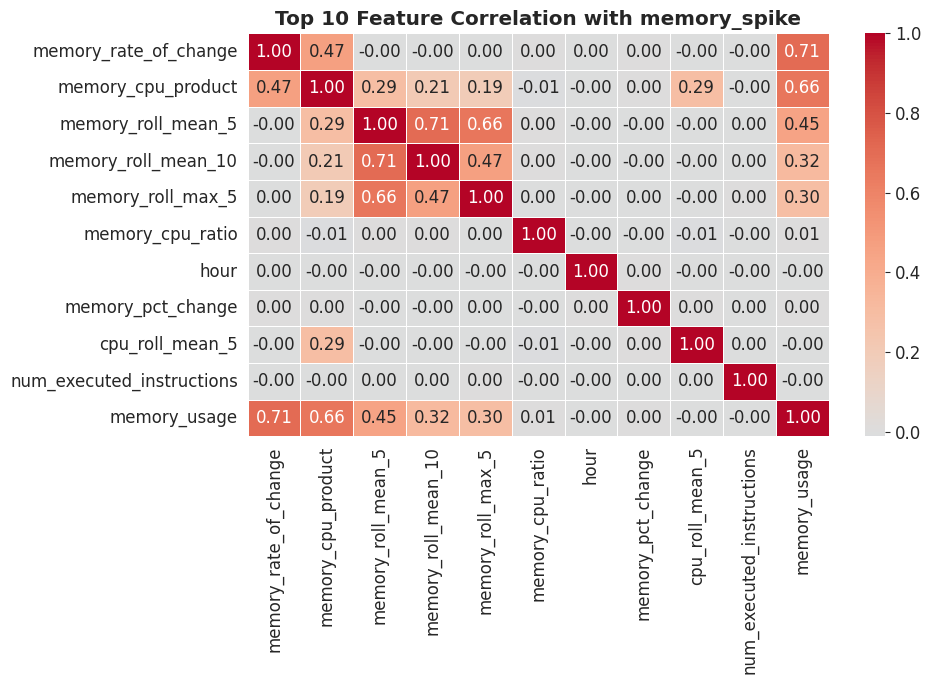

 Saved: correlation_heatmap.png


In [ ]:
# Top 10 features most correlated with memory_spike
corr = df[feature_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
top10 = corr.abs().sort_values(ascending=False).head(10).index.tolist()

print(' Top 10 features correlated with memory_spike:')
print(corr[top10].round(4))

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[top10 + [TARGET_COL]].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5
)
plt.title('Top 10 Feature Correlation with memory_spike', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: correlation_heatmap.png')

In [ ]:
import pickle

In [ ]:
# Save numpy arrays for LSTM notebook
import os
project_folder = os.path.dirname(DATASET_PATH)

np.save(os.path.join(project_folder, 'X_train.npy'), X_train)
np.save(os.path.join(project_folder, 'X_val.npy'),   X_val)
np.save(os.path.join(project_folder, 'X_test.npy'),  X_test)
np.save(os.path.join(project_folder, 'y_train.npy'), y_train)
np.save(os.path.join(project_folder, 'y_val.npy'),   y_val)
np.save(os.path.join(project_folder, 'y_test.npy'),  y_test)

# Save scaler & encoders
with open(os.path.join(project_folder, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(project_folder, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(label_encoders, f)


df_scaled.to_csv(os.path.join(project_folder, 'preprocessed_data.csv'), index=False)

print(' All outputs saved!')
print(f"   → {os.path.join(project_folder, 'X_train.npy')}, {os.path.join(project_folder, 'X_val.npy')}, {os.path.join(project_folder, 'X_test.npy')}")
print(f"   → {os.path.join(project_folder, 'y_train.npy')}, {os.path.join(project_folder, 'y_val.npy')}, {os.path.join(project_folder, 'y_test.npy')}")
print(f"   → {os.path.join(project_folder, 'scaler.pkl')}, {os.path.join(project_folder, 'label_encoders.pkl')}")
print(f"   → {os.path.join(project_folder, 'preprocessed_data.csv')}")

 All outputs saved!
   → /content/drive/MyDrive/Capstone/Project/X_train.npy, /content/drive/MyDrive/Capstone/Project/X_val.npy, /content/drive/MyDrive/Capstone/Project/X_test.npy
   → /content/drive/MyDrive/Capstone/Project/y_train.npy, /content/drive/MyDrive/Capstone/Project/y_val.npy, /content/drive/MyDrive/Capstone/Project/y_test.npy
   → /content/drive/MyDrive/Capstone/Project/scaler.pkl, /content/drive/MyDrive/Capstone/Project/label_encoders.pkl
   → /content/drive/MyDrive/Capstone/Project/preprocessed_data.csv
